# Bayesov klasifikator i Naive Bayes

***Linkovi na filmice:***
- https://www.youtube.com/watch?v=9wCnvr7Xw4E
- https://www.youtube.com/watch?v=O2L2Uv9pdDA
- https://www.youtube.com/watch?v=H3EjCKtlVog


In [ ]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
from scipy.stats import linregress

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

base_path = '../../data/all_sorted'
classes = ['BIC', 'CAR', 'HEAVY', 'MC']

## Pretprocesiranje i ekstrakcija znacajki

In [32]:
def remove_mains_hum(y, sr, hum_freqs=(50, 100, 150, 200), Q=30):
    """Uski notch filter na mreznoj frekvenciji i njenim harmonicima. Q=30 znaci vrlo uzak
    filter - makne samo usku vrpcu oko svake frekvencije, ne dira okolni spektar."""
    y_filt = y.copy()
    for f0 in hum_freqs:
        if f0 >= sr / 2:
            continue
        b, a = signal.iirnotch(f0, Q, sr)
        y_filt = signal.filtfilt(b, a, y_filt)
    return y_filt


def highpass(y, sr, cutoff=15, order=4):
    """Blagi high-pass da uklonimo vrlo niske frekvencije koje nam ne trebaju, koje mogu biti
    samo sum."""
    sos = signal.butter(order, cutoff, btype='highpass', fs=sr, output='sos')
    return signal.sosfiltfilt(sos, y)


def preprocess(y, sr):
    y = remove_mains_hum(y, sr)
    y = highpass(y, sr)
    return y

In [33]:
LOW_BAND = (0, 300)
MID_BAND = (300, 2000)
HIGH_BAND = (2000, 11025)


def fft_psd(y, sr):
    window = np.hanning(len(y))
    y_win = y * window

    fft = np.fft.rfft(y_win)
    psd = np.abs(fft) ** 2

    freqs = np.fft.rfftfreq(len(y), 1 / sr)
    return freqs, psd


def band_energy_ratios(freqs, psd):
    total = psd.sum() + 1e-12

    def band_frac(lo, hi):
        mask = (freqs >= lo) & (freqs < hi)
        return psd[mask].sum() / total

    return band_frac(*LOW_BAND), band_frac(*MID_BAND), band_frac(*HIGH_BAND)


def spectral_slope(freqs, psd, f_min=20, f_max=4000):
    mask = (freqs >= f_min) & (freqs <= f_max) & (psd > 0)
    if mask.sum() < 2:
        return 0.0
    log_f = np.log10(freqs[mask])
    log_p = np.log10(psd[mask])
    slope, _, _, _, _ = linregress(log_f, log_p)
    return slope


def bandwidth_low_band(freqs, psd):
    lo, hi = LOW_BAND
    mask = (freqs >= lo) & (freqs < hi)
    f = freqs[mask]
    p = psd[mask]
    if p.sum() <= 0:
        return 0.0
    centroid = np.average(f, weights=p)
    return np.sqrt(np.average((f - centroid) ** 2, weights=p))


def extract_features(y, sr):
    freqs, psd = fft_psd(y, sr)

    rms = np.mean(librosa.feature.rms(y=y))
    zcr = np.mean(librosa.feature.zero_crossing_rate(y))
    centroid = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr))
    rolloff = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
    low_e, mid_e, high_e = band_energy_ratios(freqs, psd)
    slope = spectral_slope(freqs, psd)
    bw_low = bandwidth_low_band(freqs, psd)

    onset_env = librosa.onset.onset_strength(y=y, sr=sr)
    flux = np.abs(np.diff(onset_env))

    flatness = librosa.feature.spectral_flatness(y=y)[0]

    y_harm, y_perc = librosa.effects.hpss(y)
    harm_energy = np.sum(y_harm ** 2)
    perc_energy = np.sum(y_perc ** 2)
    harmonic_ratio = harm_energy / (harm_energy + perc_energy + 1e-12)

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=5)

    feats = {
        'rms': rms,
        'zcr': zcr,
        'spectral_centroid': centroid,
        'spectral_bandwidth': bandwidth,
        'spectral_rolloff': rolloff,
        'low_band_energy': low_e,
        'mid_band_energy': mid_e,
        'high_band_energy': high_e,
        'spectral_slope': slope,
        'bandwidth_low_band': bw_low,
        'flux_mean': np.mean(flux),
        'flux_std': np.std(flux),
        'spectral_flatness_mean': np.mean(flatness),
        'spectral_flatness_std': np.std(flatness),
        'harmonic_ratio': harmonic_ratio,
    }

    for i in range(5):
        feats[f'mfcc_{i}_mean'] = np.mean(mfcc[i])
        feats[f'mfcc_{i}_std'] = np.std(mfcc[i])

    return feats

In [35]:
CACHE_PATH = '../../data/features_cache/znacajke_cache.pkl'

if os.path.exists(CACHE_PATH):
    # Znacajke su vec izracunate i spremljene - samo ucitamo gotov DataFrame
    df = pd.read_pickle(CACHE_PATH)
    print(f"Znacajke ucitane iz cachea: {CACHE_PATH} ({len(df)} uzoraka)")
else:
    data = []

    for label in classes:
        folder = os.path.join(base_path, label)
        files = [f for f in os.listdir(folder) if f.endswith('.wav')]

        for i, file in enumerate(files):
            path = os.path.join(folder, file)

            if i % 10 == 0:
                print(f"   {label}: {i}/{len(files)} -> {file}")

            y, sr = librosa.load(path, sr=None)
            y = y[:sr * 2]  # CLIP_SECONDS = 2
            y = preprocess(y, sr)

            feats = extract_features(y, sr)
            feats['label'] = label
            data.append(feats)

    print(f"\nGotovo! Ukupno uzoraka: {len(data)}")

    df = pd.DataFrame(data)
    df = df[[c for c in df.columns if c != 'label'] + ['label']]

    df.to_pickle(CACHE_PATH)
    print(f"Znacajke spremljene u cache: {CACHE_PATH}")

print("\nBroj uzoraka po klasi (provjera balansa):")
print(df['label'].value_counts())

X = df.drop(columns=['label'])
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

df.head()

Znacajke ucitane iz cachea: ../../data/features_cache/znacajke_cache.pkl (11391 uzoraka)

Broj uzoraka po klasi (provjera balansa):
label
CAR      9348
HEAVY    1190
MC        519
BIC       334
Name: count, dtype: int64


,rms,zcr,spectral_centroid,spectral_bandwidth,spectral_rolloff,low_band_energy,mid_band_energy,high_band_energy,spectral_slope,bandwidth_low_band,...,mfcc_0_std,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,mfcc_3_mean,mfcc_3_std,mfcc_4_mean,mfcc_4_std,label
0,0.065307,0.019609,1826.503815,3078.726276,3590.425532,0.885687,0.101071,0.013052,-1.867504,45.903706,...,10.003626,178.775146,8.686232,-21.621541,5.821289,36.673271,4.580609,-1.047381,4.811483,BIC
1,0.035374,0.015698,2076.097549,4056.747926,4311.128657,0.971927,0.026018,0.001874,-2.311674,32.781818,...,22.649855,156.664657,11.681949,12.578587,7.050431,34.767883,6.372147,6.526522,8.544958,BIC
2,0.023371,0.036772,2588.184819,4263.899547,5891.040559,0.606855,0.378988,0.010833,-2.257224,65.991067,...,19.032952,167.932851,13.178547,2.001518,8.522644,37.542249,6.599697,-10.102805,7.831448,BIC
3,0.015145,0.041662,3539.687221,4993.381655,8676.861702,0.865271,0.112723,0.016721,-1.862074,42.518202,...,28.413603,140.353747,20.136714,-1.482174,10.328294,31.438115,6.909532,-8.179644,7.339408,BIC
4,0.005752,0.153959,4113.331616,4369.290481,9066.073803,0.322573,0.342152,0.329180,-1.000743,84.206649,...,13.254949,133.573605,16.001052,-39.154997,12.569525,36.705386,7.314667,-15.412616,6.875457,BIC


In [36]:
def evaluate_model_cv(model, X, y):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X, y, cv=cv, scoring='f1_macro')
    
    print("Macro F1 po foldovima:", scores)
    print(f"Prosjek: {scores.mean():.3f} ± {scores.std():.3f}")
    
    return scores.mean()

## 1. Teorijska podloga

### Bayesov teorem

Sve pocinje iz jedne formule:

$$P(y \mid x) = \frac{P(x \mid y) \, P(y)}{P(x)}$$

gdje je za nas problem (klasifikacija zvuka vozila u jednu od 4 klase):

- $P(y)$ - **prior**, koliko cesto se ta klasa uopce pojavljuje bez ikakvog podatka o zvuku
  (kod nas jako neravnomjerno - CAR cca 82% uzoraka, BIC svega 3%)
- $P(x \mid y)$ - **likelihood**, koliko je "tipican" ovakav skup znacajki $x$ za danu klasu
  $y$ (npr. kolika je vjerojatnost da HEAVY vozilo ima bas ovu kombinaciju spektralnog
  centroida, MFCC-a, itd.)
- $P(x)$ - **evidencija**, vjerojatnost da uopce vidimo bas ovaj $x$, bez obzira na klasu -
  radi normalizacije da posteriori zbrajaju na 1
- $P(y \mid x)$ - **posterior**, ono sto nas zapravo zanima: kolika je vjerojatnost svake
  klase NAKON sto smo vidjeli konkretne znacajke uzorka

Za klasifikaciju ne moramo racunati $P(x)$ eksplicitno - isti je za sve klase pa ne utjece
na to koja klasa "pobjedi", pa biramo klasu koja maksimizira brojnik (MAP - maximum a
posteriori pravilo):

$$\hat{y} = \arg\max_{y} \; P(x \mid y) \, P(y)$$

Ovo je bitna konceptualna razlika od DecisionTree/RandomForest/XGBoost notebookova - oni su
**diskriminativni** modeli (direktno uce granicu odluke izmedju klasa), dok je Bayesov
klasifikator **generativan** - modelira kako svaka klasa "generira" znacajke ($P(x|y)$), pa
onda Bayesovim teoremom to okrene u odluku o klasi.

### "Puni" Bayesov klasifikator (bez pretpostavke nezavisnosti) - QDA

Ako $x$ ima $d$ znacajki (kod nas $d=26$), $P(x \mid y)$ je zajednicka (joint) razdioba svih
26 znacajki odjednom, za svaku klasu posebno. Najcesci izbor je multivarijatna normalna
razdioba:

$$P(x \mid y=k) = \mathcal{N}(x; \mu_k, \Sigma_k)$$

gdje $\Sigma_k$ nije samo popis varijanci nego **puna kovarijacijska matrica** - hvata i
korelacije izmedju svakog para znacajki (npr. koliko su `spectral_bandwidth` i
`spectral_rolloff` medjusobno povezani UNUTAR klase CAR).

Ovo se zove **Quadratic Discriminant Analysis (QDA)** u sklearnu - "kvadratna" jer granica
odluke izmedju dvije klase ispadne kvadratna ploha (posljedica toga sto svaka klasa ima
SVOJU $\Sigma_k$, pa se kod izjednacavanja dva log-posteriora kvadratni clanovi ne skrate).

**Problem**: broj parametara u $\Sigma_k$ raste kao $d(d+1)/2$ - za nas $d=26$ to je 351
parametara PO klasi (kovarijance + varijance), puta 4 klase = 1404 parametra samo za
kovarijacijsku strukturu. Klasa BIC ima svega 334 uzoraka ukupno (jos manje nakon train/test
splita), blizu smo situaciji gdje imamo vise parametara nego podataka po klasi, sto
kovarijacijsku matricu cini nestabilnom (skoro singularnom) i procjenu jako varijabilnom.

### Naivni Bayes (Naive Bayes)

Naivni Bayes rjesava bas taj problem eksplozije parametara jednom (jakom) pretpostavkom:
**uvjetna nezavisnost znacajki, dan razred**:

$$P(x \mid y) = \prod_{j=1}^{d} P(x_j \mid y)$$

Umjesto jedne 26-dimenzionalne zajednicke razdiobe po klasi, sada racunamo 26 zasebnih
1-dimenzionalnih razdioba po klasi - kovarijacijska matrica $\Sigma_k$ se svodi na dijagonalnu
matricu (samo varijance, sve kovarijance = 0 po pretpostavci). Broj parametara pada s
$d(d+1)/2$ na samo $d$ po klasi - **26 umjesto 351**.

Ovo je klasican **bias-varijanca kompromis** (isti princip kao Decision Tree vs Random Forest,
samo primijenjen na procjenu vjerojatnosti umjesto na granicu odluke):

- QDA: nizak bias (ne pretpostavlja nista o strukturi $\Sigma_k$, moze uhvatiti stvarne
  korelacije), ali visoka varijanca procjene kad je podataka po klasi malo (BIC, MC)
- Naive Bayes: visok bias (pretpostavka nezavisnosti je gotovo sigurno kriva - vidjet cemo u
  korelacijskoj matrici nize da npr. `spectral_bandwidth` i `spectral_rolloff` ocito NISU
  nezavisni), ali niska varijanca jer ima puno manje parametara za procijeniti

Zanimljivo je da to sto je pretpostavka "kriva" ne mora znaciti da je klasifikacija losa -
tocnost ovisi samo o tome je li $\arg\max$ ispravan, ne o tome koliko su same procijenjene
vjerojatnosti tocne - [**VIDJETI izvor7**]. Opcenitiji pregled o Naive Bayesu - [**VIDJETI izvor8**]. Empirijski, steta od
krsenja pretpostavke ovisi o TOME KOLIKO su znacajke korelirane (najgore je bas u "srednjem"
podrucju umjerene korelacije, ne u ekstremima) - [**VIDJETI izvor9**].

### Zasto Gaussian varijanta?

Naive Bayes dolazi u vise varijanti, ovisno o tome kakvu razdiobu pretpostavimo za
$P(x_j \mid y)$:

- **GaussianNB** - za kontinuirane znacajke (nas slucaj: RMS, spektralni centroid, MFCC-i su
  sve realni brojevi), pretpostavlja $P(x_j \mid y=k) = \mathcal{N}(x_j; \mu_{jk},
  \sigma_{jk}^2)$ - normalna razdioba po svakoj znacajki i klasi
- **MultinomialNB** / **BernoulliNB** - za brojanja (npr. broj pojavljivanja rijeci u tekstu)
  ili binarne znacajke - nama ne odgovaraju jer nase znacajke nisu diskretne

Zato u primjeni nize koristimo iskljucivo `sklearn.naive_bayes.GaussianNB`.

## 2. Primjena na dataset

Prije treniranja, provjerimo empirijski koliko je pretpostavka nezavisnosti realna za nas
skup znacajki - racunamo korelacijsku matricu na train skupu. Sto su korelacije jace
(pozitivno ili negativno), to je pretpostavka Naive Bayesa vise krsena.

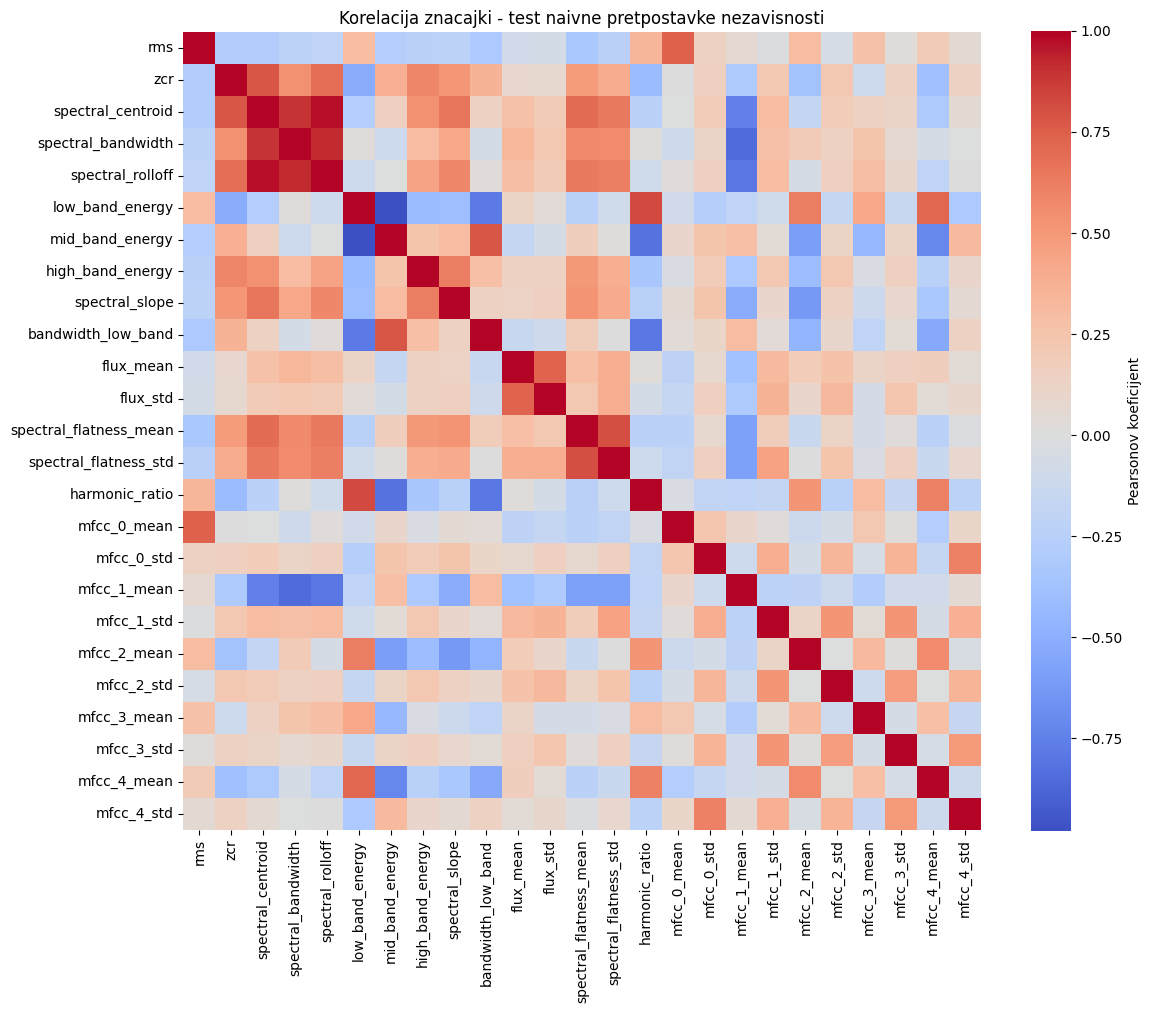

Top 10 najjace koreliranih parova znacajki:
low_band_energy         mid_band_energy          0.979004
spectral_centroid       spectral_rolloff         0.970326
spectral_bandwidth      spectral_rolloff         0.918140
spectral_centroid       spectral_bandwidth       0.894110
spectral_bandwidth      mfcc_1_mean              0.850085
low_band_energy         harmonic_ratio           0.826483
mid_band_energy         harmonic_ratio           0.816599
spectral_flatness_mean  spectral_flatness_std    0.814245
spectral_rolloff        mfcc_1_mean              0.796523
bandwidth_low_band      harmonic_ratio           0.792862
dtype: float64


In [5]:
corr = X_train.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', center=0, square=True, cbar_kws={'label': 'Pearsonov koeficijent'})
plt.title('Korelacija znacajki - test naivne pretpostavke nezavisnosti')
plt.tight_layout()
plt.show()

# najjace korelirani parovi znacajki (van dijagonale)
corr_pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
print("Top 10 najjace koreliranih parova znacajki:")
print(corr_pairs.abs().sort_values(ascending=False).head(10))

Ocekivano, dosta parova je jako korelirano (npr. `spectral_bandwidth` i `spectral_rolloff`
mjere slicnu stvar - sirinu/rasap spektra). Naive Bayes ce ove korelirane parove tretirati kao potpuno nezavisne, sto po
teoriji iz izvor9 znaci da smo bas u "srednjem" podrucju gdje bi razlika prema QDA (koji
korelacije modelira) trebala biti najvidljivija.

### Naive Bayes (GaussianNB)

Za pocetak koristimo default ponasanje - `GaussianNB` bez eksplicitnog zadavanja priora sam
procjenjuje $P(y)$ iz udjela klasa u trening skupu. Buduci da je CAR cca 82% podataka, ovo
znaci da prior snazno gura odluku prema CAR (isto ono sto smo kod DT/RF rjesavali sa
`class_weight='balanced'` - GaussianNB nema `class_weight`, ali ima `priors` koji radi
analognu stvar direktno kroz $P(y)$ u Bayesovoj formuli).

In [15]:
from sklearn.naive_bayes import GaussianNB

clf_nb = GaussianNB()
clf_nb.fit(X_train, y_train)

train_acc = clf_nb.score(X_train, y_train)
test_acc = clf_nb.score(X_test, y_test)
print(f"Train accuracy: {train_acc:.3f}")
print(f"Test accuracy:  {test_acc:.3f}")
print(f"Naucen prior P(y) po klasi: {dict(zip(clf_nb.classes_, clf_nb.class_prior_.round(3)))}")

Train accuracy: 0.781
Test accuracy:  0.783
Naucen prior P(y) po klasi: {np.str_('BIC'): np.float64(0.029), np.str_('CAR'): np.float64(0.821), np.str_('HEAVY'): np.float64(0.104), np.str_('MC'): np.float64(0.046)}


              precision    recall  f1-score   support

         BIC       0.24      0.54      0.33        83
         CAR       0.92      0.85      0.89      2337
       HEAVY       0.39      0.50      0.44       298
          MC       0.38      0.38      0.38       130

    accuracy                           0.78      2848
   macro avg       0.48      0.57      0.51      2848
weighted avg       0.82      0.78      0.80      2848



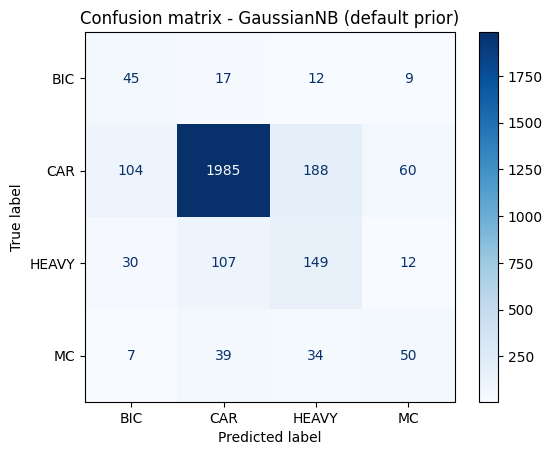

In [7]:
y_pred = clf_nb.predict(X_test)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=clf_nb.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf_nb.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion matrix - GaussianNB (default prior)')
plt.show()

### Naive Bayes s uravnotezenim priorom

Kod Bayesovog klasifikatora, za razliku od DT/RF/XGBoost, "balansiranje" nije posredna
promjena tezina u funkciji gubitka - prior $P(y)$ je doslovno dio formule, pa ga mozemo
direktno postaviti na uniformnu razdiobu (svaka klasa 25%) preko `priors` parametra i time
eksplicitno reci modelu "ignoriraj koliko je koja klasa cesta, gledaj samo likelihood
$P(x|y)$".

Train accuracy (uniform prior): 0.725
Test accuracy (uniform prior):  0.723
              precision    recall  f1-score   support

         BIC       0.21      0.64      0.32        83
         CAR       0.94      0.76      0.84      2337
       HEAVY       0.33      0.55      0.41       298
          MC       0.26      0.44      0.33       130

    accuracy                           0.72      2848
   macro avg       0.44      0.60      0.48      2848
weighted avg       0.83      0.72      0.76      2848



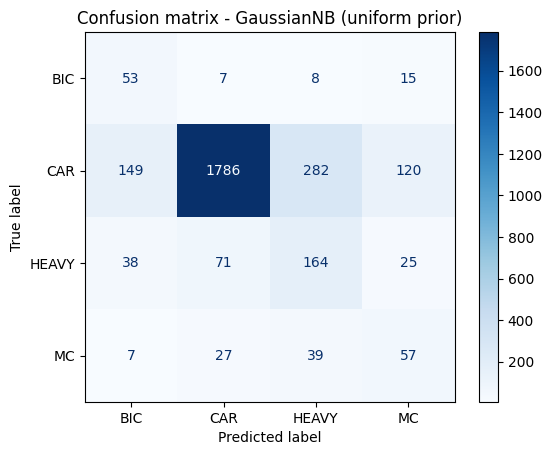

Usporedba: ukupna accuracy ce vjerojatno pasti (manje CAR-a pogodjeno jer prior vise
ne gura sve prema CAR), ali macro-f1 bi trebao rasti jer se manje klase (BIC/MC) bolje
prepoznaju - isti fenomen kao balansiranje kod DT/RF, samo eksplicitno kroz P(y).


In [16]:
clf_nb_bal = GaussianNB(priors=[0.25, 0.25, 0.25, 0.25]) # ovdje definiramo da su svi priori isti
clf_nb_bal.fit(X_train, y_train)

train_acc_bal = clf_nb_bal.score(X_train, y_train)
test_acc_bal = clf_nb_bal.score(X_test, y_test)
print(f"Train accuracy (uniform prior): {train_acc_bal:.3f}")
print(f"Test accuracy (uniform prior):  {test_acc_bal:.3f}")

y_pred_bal = clf_nb_bal.predict(X_test)
print(classification_report(y_test, y_pred_bal))

cm_bal = confusion_matrix(y_test, y_pred_bal, labels=clf_nb_bal.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_bal, display_labels=clf_nb_bal.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion matrix - GaussianNB (uniform prior)')
plt.show()

print("Usporedba: ukupna accuracy ce vjerojatno pasti (manje CAR-a pogodjeno jer prior vise\n"
      "ne gura sve prema CAR), ali macro-f1 bi trebao rasti jer se manje klase (BIC/MC) bolje\n"
      "prepoznaju - isti fenomen kao balansiranje kod DT/RF, samo eksplicitno kroz P(y).")

#zanimljivo je sto je pao i accoracy i macrof1, to znaci da se niti manje klase nisu uspjesno prepoznale

### "Puni" Bayesov klasifikator (QDA)

Sada probajmo verziju BEZ pretpostavke nezavisnosti - `QuadraticDiscriminantAnalysis` uci
punu kovarijacijsku matricu po klasi. Ocekujemo (iz teorije iznad) da bi ovo moglo biti
nestabilno bas za male klase (BIC, MC) gdje broj uzoraka nije puno veci od broja parametara
kovarijacijske matrice (351 po klasi).

In [13]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

clf_qda = QuadraticDiscriminantAnalysis(priors=[0.25, 0.25, 0.25, 0.25])
clf_qda.fit(X_train, y_train)

train_acc_qda = clf_qda.score(X_train, y_train)
test_acc_qda = clf_qda.score(X_test, y_test)
print(f"Train accuracy: {train_acc_qda:.3f}")
print(f"Test accuracy:  {test_acc_qda:.3f}")

y_pred_qda = clf_qda.predict(X_test)
print(classification_report(y_test, y_pred_qda))

cm_qda = confusion_matrix(y_test, y_pred_qda, labels=clf_qda.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_qda, display_labels=clf_qda.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion matrix - QDA (uniform prior)')
plt.show()

LinAlgError: The covariance matrix of class BIC is not full rank. Increase the value of `reg_param` to reduce the collinearity.

Gore je ispisano upozorenje tj. error(`Variables are collinear`) - to je direktna posljedica
onoga sto smo predvidjeli u teoriji: kovarijacijska matrica neke klase (dakle BIC koji ima najmanje uzoraka) je blizu singularne jer nemamo dovoljno podataka da pouzdano
procijenimo svih 351 parametara. Regularizacija (`reg_param`) to rjesava "smanjivanjem" pune
kovarijacijske matrice prema dijagonalnoj (zajednickoj) - sto je zapravo blagi pomak PREMA
Naive Bayesu, samo djelomican.

In [39]:
clf_qda_reg = QuadraticDiscriminantAnalysis(priors=[0.25, 0.25, 0.25, 0.25], reg_param=0.1)
clf_qda_reg.fit(X_train, y_train)

train_acc_qda_reg = clf_qda_reg.score(X_train, y_train)
test_acc_qda_reg = clf_qda_reg.score(X_test, y_test)
print(f"Train accuracy (reg_param=0.1): {train_acc_qda_reg:.3f}")
print(f"Test accuracy (reg_param=0.1):  {test_acc_qda_reg:.3f}")

y_pred_qda_reg = clf_qda_reg.predict(X_test)
print(classification_report(y_test, y_pred_qda_reg))

Train accuracy (reg_param=0.1): 0.769
Test accuracy (reg_param=0.1):  0.753
              precision    recall  f1-score   support

         BIC       0.22      0.66      0.34        83
         CAR       0.95      0.78      0.86      2337
       HEAVY       0.39      0.67      0.49       298
          MC       0.38      0.46      0.42       130

    accuracy                           0.75      2848
   macro avg       0.48      0.65      0.53      2848
weighted avg       0.84      0.75      0.78      2848



In [37]:
models = {
    "Naive Bayes": GaussianNB(),
    "NB (uniform)": GaussianNB(priors=[0.25]*4),
    "QDA reg=0.1": QuadraticDiscriminantAnalysis(priors=[0.25]*4, reg_param=0.1),
}

results = {}

for name, model in models.items():
    print(f"\n{name}")
    score = evaluate_model_cv(model, X_train, y_train)
    results[name] = score


Naive Bayes
Macro F1 po foldovima: [0.52068146 0.46896974 0.53897106 0.48437929 0.51732006]
Prosjek: 0.506 ± 0.026

NB (uniform)
Macro F1 po foldovima: [0.50443263 0.45739805 0.48631115 0.45881056 0.48351232]
Prosjek: 0.478 ± 0.018

QDA reg=0.1
Macro F1 po foldovima: [0.5473246  0.522514   0.5369877  0.52227693 0.53466026]
Prosjek: 0.533 ± 0.009


### ***QDA tuning preko StratifiedKFold***

In [68]:

# redoslijed: BIC, CAR, HEAVY, MC
"""priors_list = [
    [0.25, 0.25, 0.25, 0.25],
    
    [0.10, 0.70, 0.15, 0.05],
    [0.10, 0.75, 0.10, 0.05],
    [0.10, 0.60, 0.15, 0.15],
    [0.15, 0.65, 0.15, 0.05],
    [0.15, 0.70, 0.10, 0.05],
    [0.15, 0.60, 0.20, 0.05],
    [0.15, 0.55, 0.15, 0.15],
    [0.15, 0.60, 0.10, 0.15],
    [0.15, 0.50, 0.20, 0.15],
    [0.20, 0.60, 0.15, 0.05],
    [0.20, 0.55, 0.15, 0.10],
    [0.20, 0.65, 0.10, 0.05],
    [0.20, 0.50, 0.15, 0.15],
    [0.20, 0.55, 0.10, 0.15],
]"""

def generate_priors(step=0.05):
    priors = []

    values = np.arange(0.05, 1.0, step)

    for bic in values:
        for car in values:
            for heavy in values:
                mc = 1 - bic - car - heavy

                if  0.03 <= bic <= 0.20 and 0.45 <= car <= 0.75 and 0.10 <= heavy <= 0.3 and 0.05 <= mc <= 0.15:
                    priors.append([round(bic, 2), round(car, 2), round(heavy, 2), round(mc, 2)])
    return priors

priors_list = generate_priors(step=0.05)


reg_params = [0.001, 0.005,0.01,0.02,0.05, 0.1]
print("Broj priora: ", len(priors_list))
print(priors_list[:10])


cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

qda_results = []

for reg in reg_params:
    for prior in priors_list:
        
        clf = QuadraticDiscriminantAnalysis(priors=prior,reg_param=reg)
        
        scores = cross_val_score(clf,X_train,y_train,cv=cv,scoring="f1_macro")
        
        qda_results.append({
            "priors": prior,
            "reg_param": reg,
            "f1_macro_mean": scores.mean(),
            "f1_macro_std": scores.std()
        })


qda_results_df = pd.DataFrame(qda_results)


qda_results_df.sort_values(by="f1_macro_mean",ascending=False).head(10)

Broj priora:  31
[[np.float64(0.05), np.float64(0.55), np.float64(0.25), np.float64(0.15)], [np.float64(0.05), np.float64(0.6), np.float64(0.2), np.float64(0.15)], [np.float64(0.05), np.float64(0.6), np.float64(0.25), np.float64(0.1)], [np.float64(0.05), np.float64(0.65), np.float64(0.15), np.float64(0.15)], [np.float64(0.05), np.float64(0.65), np.float64(0.2), np.float64(0.1)], [np.float64(0.05), np.float64(0.7), np.float64(0.1), np.float64(0.15)], [np.float64(0.05), np.float64(0.7), np.float64(0.15), np.float64(0.1)], [np.float64(0.05), np.float64(0.75), np.float64(0.1), np.float64(0.1)], [np.float64(0.1), np.float64(0.55), np.float64(0.2), np.float64(0.15)], [np.float64(0.1), np.float64(0.55), np.float64(0.25), np.float64(0.1)]]


,priors,reg_param,f1_macro_mean,f1_macro_std
2,"[0.05, 0.6, 0.25, 0.1]",0.001,0.571487,0.022754
4,"[0.05, 0.65, 0.2, 0.1]",0.001,0.570559,0.025597
32,"[0.05, 0.6, 0.2, 0.15]",0.005,0.569411,0.019463
63,"[0.05, 0.6, 0.2, 0.15]",0.010,0.569333,0.020956
35,"[0.05, 0.65, 0.2, 0.1]",0.005,0.569229,0.019463
11,"[0.1, 0.6, 0.2, 0.1]",0.001,0.569102,0.024544
0,"[0.05, 0.55, 0.25, 0.15]",0.001,0.569081,0.022818
9,"[0.1, 0.55, 0.25, 0.1]",0.001,0.568890,0.022325
33,"[0.05, 0.6, 0.25, 0.1]",0.005,0.567989,0.019805
42,"[0.1, 0.6, 0.2, 0.1]",0.005,0.567627,0.019527


In [ ]:
# najbolja kombo
best_qda_params = qda_results_df.sort_values(by="f1_macro_mean",ascending=False).iloc[0]
print(best_qda_params)

priors           [0.05, 0.6, 0.25, 0.1]
reg_param                         0.001
f1_macro_mean                  0.571487
f1_macro_std                   0.022754
Name: 2, dtype: object


In [ ]:
# treniranje na najboljem skupu
best_prior = best_qda_params["priors"]
best_reg = best_qda_params["reg_param"]

clf_qda_tuned = QuadraticDiscriminantAnalysis(priors=best_prior,reg_param=best_reg)
clf_qda_tuned.fit(X_train,y_train)
y_pred_qda = clf_qda_tuned.predict(X_test)

train_acc_qda_reg = clf_qda_tuned.score(X_train, y_train)
test_acc_qda_reg = clf_qda_tuned.score(X_test, y_test)

print(f"Train accuracy (reg_param=0.1): {train_acc_qda_reg:.3f}")
print(f"Test accuracy (reg_param=0.1):  {test_acc_qda_reg:.3f}")
print(classification_report(y_test, y_pred_qda, target_names=classes))

Train accuracy (reg_param=0.1): 0.823
Test accuracy (reg_param=0.1):  0.815
              precision    recall  f1-score   support

         BIC       0.29      0.52      0.37        83
         CAR       0.92      0.88      0.90      2337
       HEAVY       0.49      0.58      0.53       298
          MC       0.46      0.41      0.43       130

    accuracy                           0.81      2848
   macro avg       0.54      0.60      0.56      2848
weighted avg       0.84      0.81      0.82      2848



## 3. Usporedba i zakljucak

| Model                          | Train acc | Test acc | Macro F1-score | Napomena |
|--------------------------------|----------:|---------:|---------:|----------|
| GaussianNB (default prior)     | 0.781     | 0.783    | 0.51     | prior = udio pravih klasa (gura prema CAR) |
| GaussianNB (uniform prior)     | 0.725     | 0.723    | 0.48     | prior = 0.25 po klasi (sve jednako) |
| QDA (uniform prior)            | X         | X        | X        | puna kovarijanca po klasi (error za BIC)|
| QDA (uniform prior, reg_param) | 0.760     | 0.743    | 0.52     | regularizirana kovarijanca |


</br>

**Usporedba QDA uniform i optimized**
| Model                          | Accuracy  | Macro precision | Macro recall | Macro F1-score |
|--------------------------------|----------:|----------------:|-------------:|----------------|
| QDA (uniform prior)            | 0.75      | 0.48            | 0.65         | 0.53           |
| QDA (optimized prior)          | 0.81      | 0.54            | 0.81         | 0.56           |

</br>

Ocekivanja na temelju teorije:

- Naive Bayes bi trebao biti brz i stabilan, ali ogranicen gornjom granicom tocnosti jer
  ignorira sve korelacije koje smo vidjeli u heatmapi (posebno izmedju spektralnih znacajki
  i susjednih MFCC koeficijenata)
- QDA bi teoretski trebao bolje uhvatiti stvarnu strukturu podataka (nizi bias), ali je
  rizik veca varijanca procjene na malim klasama (BIC, MC) - QDA bez regularizacije
  ne moze se niti izvrsit
- Oba Bayesova modela su **generativna** pa zaostaju za diskriminativnim
  ansamblima (Random Forest, XGBoost iz prethodnih notebookova) na cistoj tocnosti - ali
  su puno brzi za trenirati i imaju jasnu probabilisticku interpretaciju (mozemo procitati
  naucene $\mu_k$, $\sigma_k^2$ i prior direktno, za razliku od stotina stabala kod RF-a)
- najbolji na malim klasama je ispao QDA